In [1]:
pip install seaborn matplotlib scikit-learn pandas

## Load the Dataset

Now that the environment is set up, the next step is to load the dataset. The provided file list shows `archive (3).zip` which likely contains the sales data. I'll need to unzip it and then load the relevant CSV file into a pandas DataFrame.

In [2]:
import zipfile

# Unzip the file
with zipfile.ZipFile('archive (3).zip', 'r') as zip_ref:
    zip_ref.extractall('.')

print("Archive unzipped successfully.")

Archive unzipped successfully.


In [4]:
import pandas as pd
import os

# The file listing showed 'advertising.csv' after unzipping.
# Now, load the CSV into a DataFrame.
df = pd.read_csv('advertising.csv')

# Display the first few rows of the DataFrame
print(df.head())

      TV  Radio  Newspaper  Sales
0  230.1   37.8       69.2   22.1
1   44.5   39.3       45.1   10.4
2   17.2   45.9       69.3   12.0
3  151.5   41.3       58.5   16.5
4  180.8   10.8       58.4   17.9


## Data Exploration and Preprocessing

Now that the data is loaded, let's explore its characteristics, check for missing values, and understand its basic statistics.

In [5]:
print("DataFrame Shape:", df.shape)
print("\nDataFrame Info:")
df.info()
print("\nMissing values per column:")
print(df.isnull().sum())

DataFrame Shape: (200, 4)

DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   TV         200 non-null    float64
 1   Radio      200 non-null    float64
 2   Newspaper  200 non-null    float64
 3   Sales      200 non-null    float64
dtypes: float64(4)
memory usage: 6.4 KB

Missing values per column:
TV           0
Radio        0
Newspaper    0
Sales        0
dtype: int64


In [6]:
print("\nDescriptive Statistics:")
print(df.describe())


Descriptive Statistics:
               TV       Radio   Newspaper       Sales
count  200.000000  200.000000  200.000000  200.000000
mean   147.042500   23.264000   30.554000   15.130500
std     85.854236   14.846809   21.778621    5.283892
min      0.700000    0.000000    0.300000    1.600000
25%     74.375000    9.975000   12.750000   11.000000
50%    149.750000   22.900000   25.750000   16.000000
75%    218.825000   36.525000   45.100000   19.050000
max    296.400000   49.600000  114.000000   27.000000


## Data Visualization

To understand the relationships between advertising spending and sales, we will now visualize the data using various plots. This will help us identify patterns and potential correlations that can be useful for our sales prediction model.

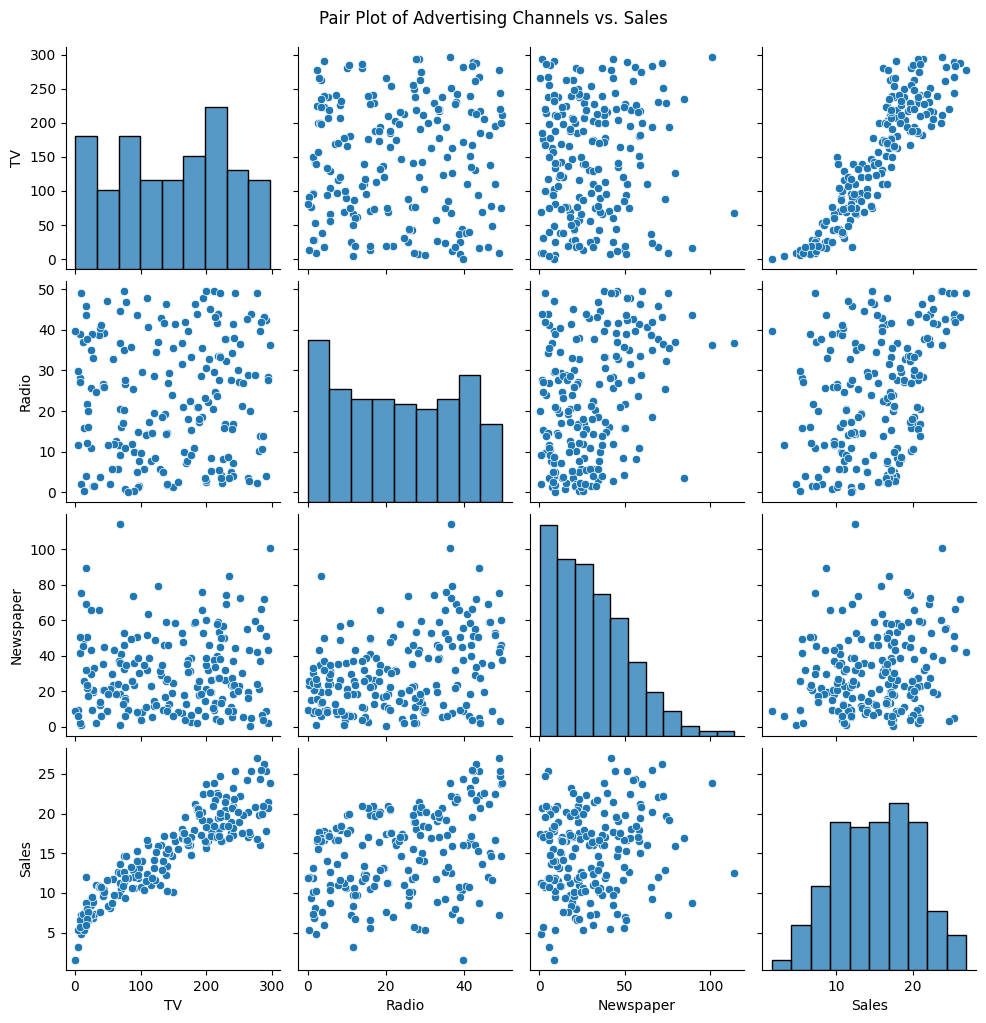

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt

# Create a pair plot to visualize relationships between all variables
sns.pairplot(df)
plt.suptitle('Pair Plot of Advertising Channels vs. Sales', y=1.02)
plt.show()

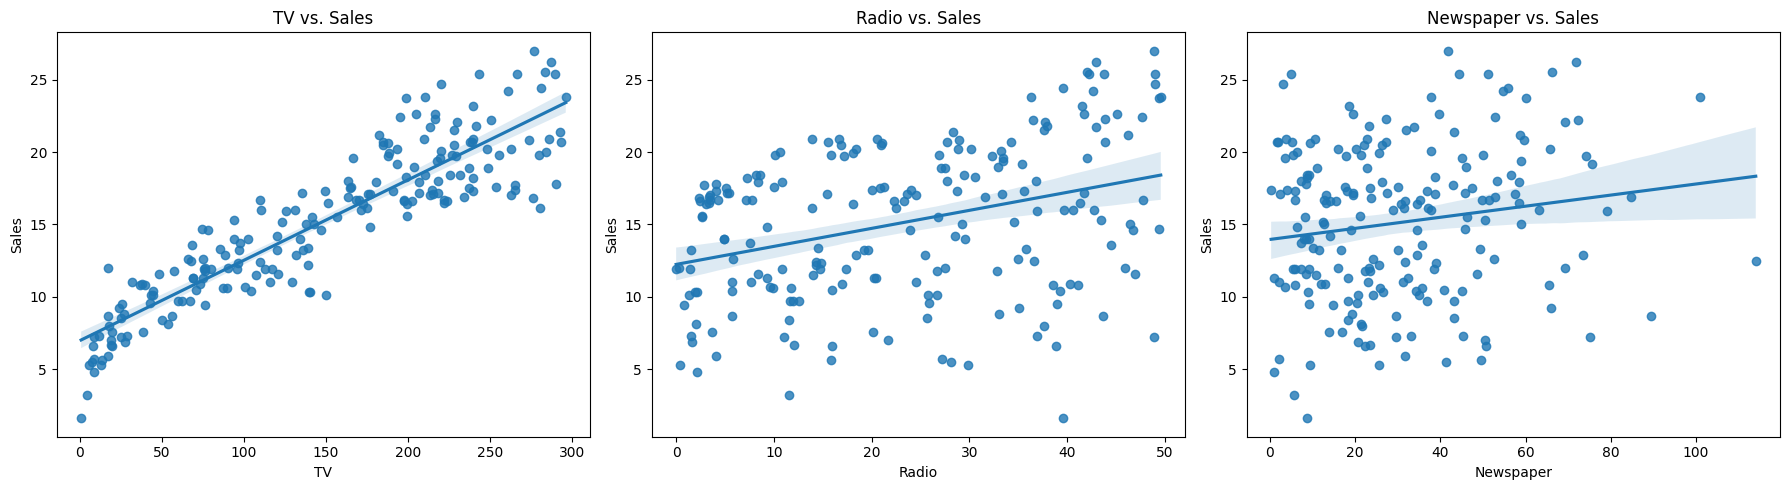

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.regplot(x='TV', y='Sales', data=df, ax=axes[0])
axes[0].set_title('TV vs. Sales')

sns.regplot(x='Radio', y='Sales', data=df, ax=axes[1])
axes[1].set_title('Radio vs. Sales')

sns.regplot(x='Newspaper', y='Sales', data=df, ax=axes[2])
axes[2].set_title('Newspaper vs. Sales')

plt.tight_layout()
plt.show()

In [9]:
print("\nCorrelation Matrix:")
print(df.corr())


Correlation Matrix:
                 TV     Radio  Newspaper     Sales
TV         1.000000  0.054809   0.056648  0.901208
Radio      0.054809  1.000000   0.354104  0.349631
Newspaper  0.056648  0.354104   1.000000  0.157960
Sales      0.901208  0.349631   0.157960  1.000000


## Model Building

Based on the visualizations and correlation analysis, we will now proceed to build a linear regression model to predict sales. We'll split the data into training and testing sets, train the model, and then evaluate its performance.

In [10]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Define features (X) and target (y)
X = df[['TV', 'Radio', 'Newspaper']]
y = df['Sales']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Data split into training and testing sets:")
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

Data split into training and testing sets:
X_train shape: (160, 3)
X_test shape: (40, 3)
y_train shape: (160,)
y_test shape: (40,)


In [11]:
# Initialize and train the Linear Regression model
model = LinearRegression()
model.fit(X_train, y_train)

print("Model training complete.")
print(f"Coefficients: {model.coef_}")
print(f"Intercept: {model.intercept_}")

Model training complete.
Coefficients: [0.05450927 0.10094536 0.00433665]
Intercept: 4.714126402214127


## Model Evaluation

Now we will evaluate the performance of our trained model on the test data.

Mean Squared Error (MSE): 2.91
R-squared (R2): 0.91


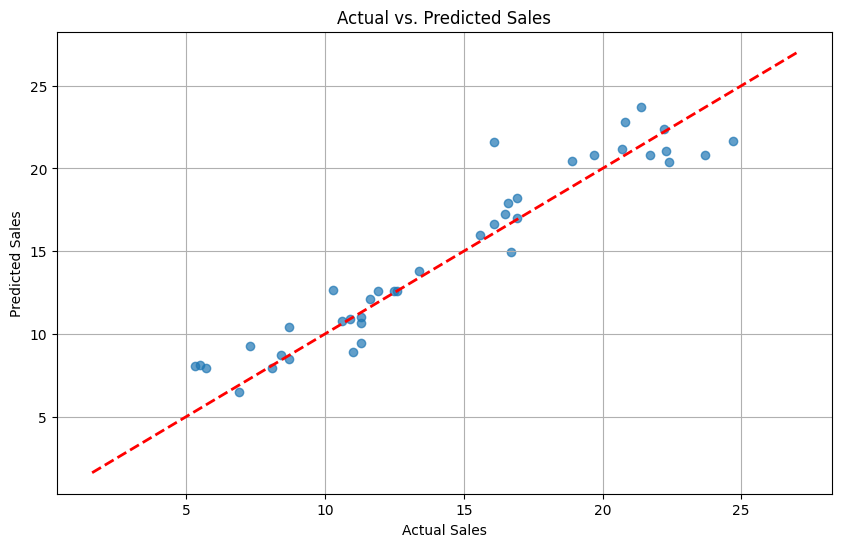

In [12]:
# Make predictions on the test set
y_pred = model.predict(X_test)

# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"R-squared (R2): {r2:.2f}")

# Plotting predictions vs actual values
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.7)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2)
plt.xlabel('Actual Sales')
plt.ylabel('Predicted Sales')
plt.title('Actual vs. Predicted Sales')
plt.grid(True)
plt.show()

## Sales Prediction

Now that our model is trained and evaluated, we can use it to predict sales based on new advertising budget allocations.

In [14]:
import numpy as np
import pandas as pd # Import pandas for DataFrame

# Example: Predict sales for new advertising expenditures
# Let's say we want to predict sales for:
# TV: 250 units
# Radio: 40 units
# Newspaper: 60 units

# Create a DataFrame with column names that match the training data
new_expenditure_df = pd.DataFrame([[250, 40, 60]], columns=['TV', 'Radio', 'Newspaper'])

# Make prediction
predicted_sales = model.predict(new_expenditure_df)

print(f"Predicted Sales for new expenditures (TV=250, Radio=40, Newspaper=60): {predicted_sales[0]:.2f} units")

Predicted Sales for new expenditures (TV=250, Radio=40, Newspaper=60): 22.64 units
